1. 대학 단위 기술통계 (n=47)
                    variable     label_ko  n  missing   mean    std    min    p10    p25  median    p75    p90    max    iqr
               rank_2024_raw 2024년 순위 원점수 47        0 24.809 14.719  1.000  5.600 12.500  24.000 36.500 44.400 52.000 24.000
              prestige_score       상위도 점수 47        0  0.533  0.289  0.000  0.149  0.304   0.549  0.775  0.910  1.000  0.471
                  a_rate_pct          A비율 47        0 43.872  8.044 28.266 36.375 37.774  41.917 46.635 55.935 63.310  8.861
                  b_rate_pct          B비율 47        0 36.286  5.104 25.885 28.190 34.269  36.566 39.419 41.507 49.358  5.150
                  c_rate_pct          C비율 47        0 15.561  5.026  5.999  8.220 11.646  16.464 19.252 21.322 27.086  7.606
                  d_rate_pct          D비율 47        0  2.090  0.668  0.873  1.244  1.545   2.127  2.602  2.801  4.082  1.057
                  f_rate_pct          F비율 47        0  2.192  0.973  0.000  1.275  1.685   1.976  2.573 

hypothesis                                     metric  estimate  ci_low  ci_high  p_value  n                         interpretation
        H1        Spearman(rank_2024_raw, a_rate_pct)   -0.4460 -0.6756  -0.1441   0.0017 47          순위 숫자가 커질수록 A비율이 낮아지는 방향이면 음수
        H1   Kendall tau-b(rank_2024_raw, a_rate_pct)   -0.3284     NaN      NaN   0.0011 47          순위 숫자가 커질수록 A비율이 낮아지는 방향이면 음수
        H1 OLS HC3 beta: prestige_score -> a_rate_pct   13.0993  4.6203  21.5783   0.0025 47 상위도 점수가 1 증가할 때 A비율 변화(%p). 방향이 맞으면 양수

해석: Spearman rho=-0.446(p=0.002, 95%CI[-0.676,-0.144]) → 중간 정도 음의 순위상관.
상위도 점수 0→1 전체 이동 시 A비율 +13.10%p 변화(HC3 p=0.002).
주의: 인과관계 아님 — '서열이 높을수록 A비율이 높은 방향의 연관'까지만 서술 가능.

3. H2 — 학점포기제 O/X와 A비율
학점포기제 유무 결측 4개교: ['한성대학교', '삼육대학교', '서경대학교', '한국공학대학교']
credit_forfeit_raw  universities  a_rate_mean_pct  a_rate_median_pct  a_rate_std_pct
                 O            19           43.992             43.465           7.371
                 X            24           45.032 


hypothesis                                                                     metric  estimate  ci_low  ci_high  p_value  effect_size  n                  interpretation
        H2                                                         mean(A rate O - X)   -1.0397 -5.7479   3.6444      NaN      -0.1281 43     양수이면 학점포기제 O 대학의 평균 A비율이 높음
        H2                                                     Welch t-test two-sided   -0.4315     NaN      NaN   0.6684      -0.1281 43          O/X 평균 차이에 대한 이분산 t 검정
        H2                                                   Mann-Whitney U two-sided  217.0000     NaN      NaN   0.7973          NaN 43            O/X 분포 차이에 대한 비모수 검정
        H2 OLS HC3 beta: credit_forfeit_bin -> a_rate_pct, controlling prestige_score   -2.5264 -7.1021   2.0493   0.2792          NaN 43 서열 프록시 통제 후 학점포기제 O의 A비율 차이(%p)

해석: O-X 평균차 -1.04%p (bootstrap 95%CI [-5.75,3.64]), Welch p=0.668, Hedges g=-0.128 → 효과크기 작음.
서열 통제 회귀: beta=-2.53%p, p=0.279 → 유의하지 않음. 학점포기제 단독으로 

findfont: Failed to find font weight bold, now using 400.


hypothesis    outcome                                                             metric  estimate  ci_low  ci_high  p_value  n                        interpretation
        H3      공식취업률                                        Spearman(A residual, 공식취업률)   -0.0394     NaN      NaN   0.7924 47 양수이면 서열 대비 A비율 잔차가 높은 대학일수록 해당 성과가 높음
        H3      공식취업률                         mean(공식취업률: low residual tertile - others)    0.2924 -2.3013   3.0497      NaN 47   음수이면 서열 대비 A 낮음 그룹의 평균 성과가 나머지보다 낮음
        H3      공식취업률      OLS HC3 beta: A residual -> 공식취업률, controlling prestige_score   -0.0212 -0.1819   0.1395   0.7963 47        A비율 잔차 1%p 증가와 성과 지표 변화의 부분 연관
        H3 건보직장가입 취업률                                   Spearman(A residual, 건보직장가입 취업률)    0.0997     NaN      NaN   0.5050 47 양수이면 서열 대비 A비율 잔차가 높은 대학일수록 해당 성과가 높음
        H3 건보직장가입 취업률                    mean(건보직장가입 취업률: low residual tertile - others)    0.6544 -2.5569   3.9424      NaN 47   음수이면 서열 대비 A 낮음 그룹의 평균 성과가 나머지보다 낮음
    

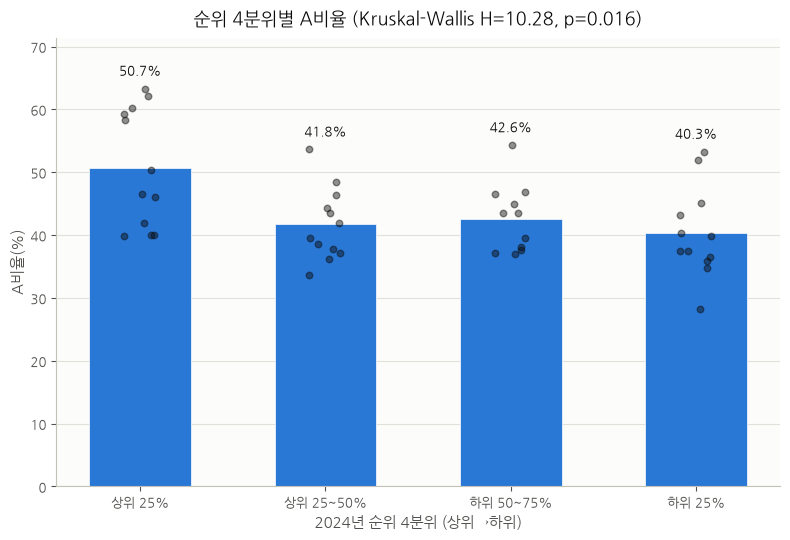

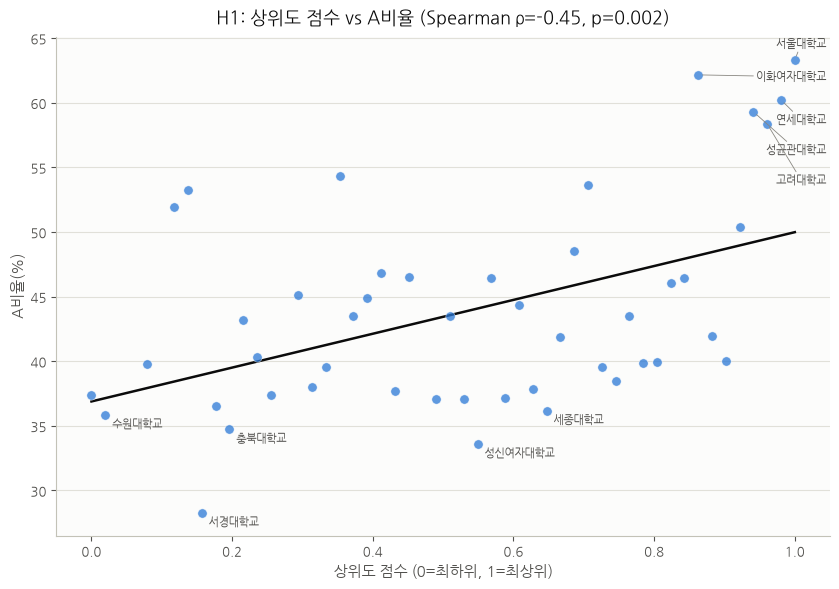

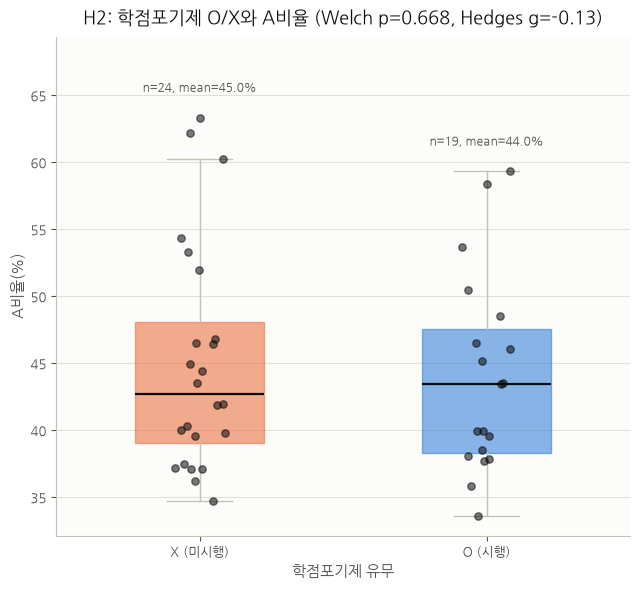

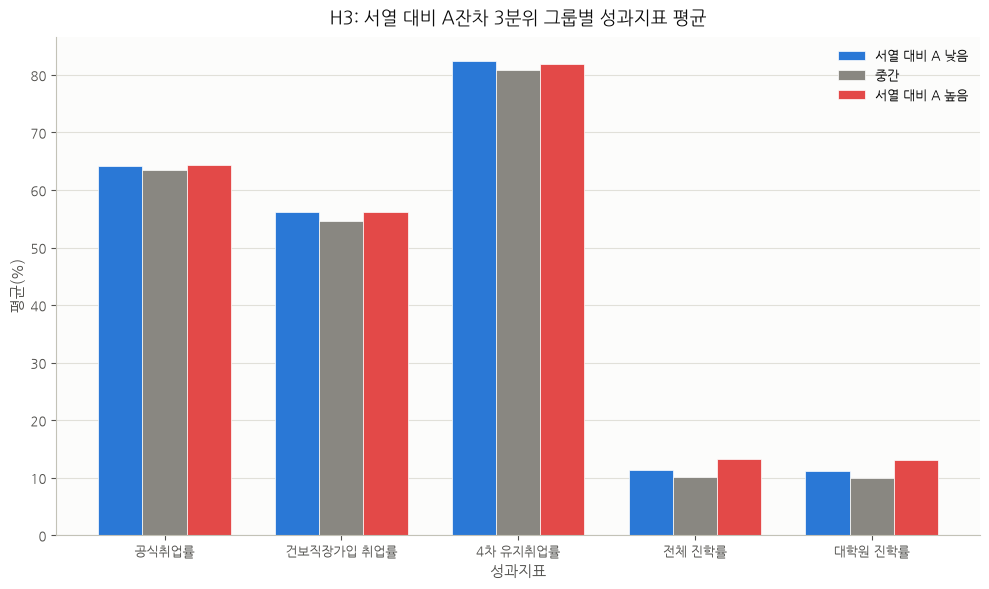

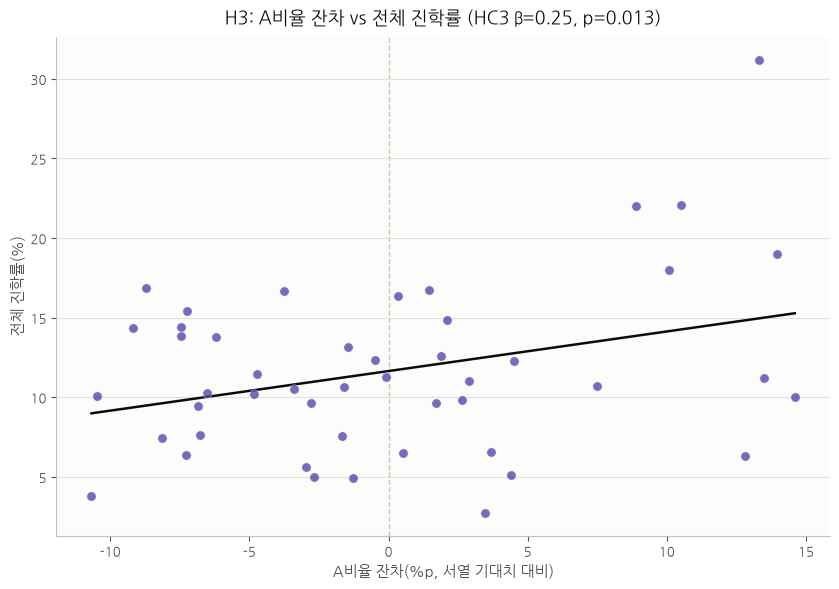

[표시 제한] 표본이 작은 8개 전공계열(예체능디자인, 컴퓨터AI, 보건의료, 법행정경찰소방, 사회복지상담심리, 간호, 관광호텔조리, 신학종교, 합계 n=774)은 '소규모 계열 합산'로 묶어 표시. 세부 수치는 06 CSV에서 major_group별로 확인 가능.


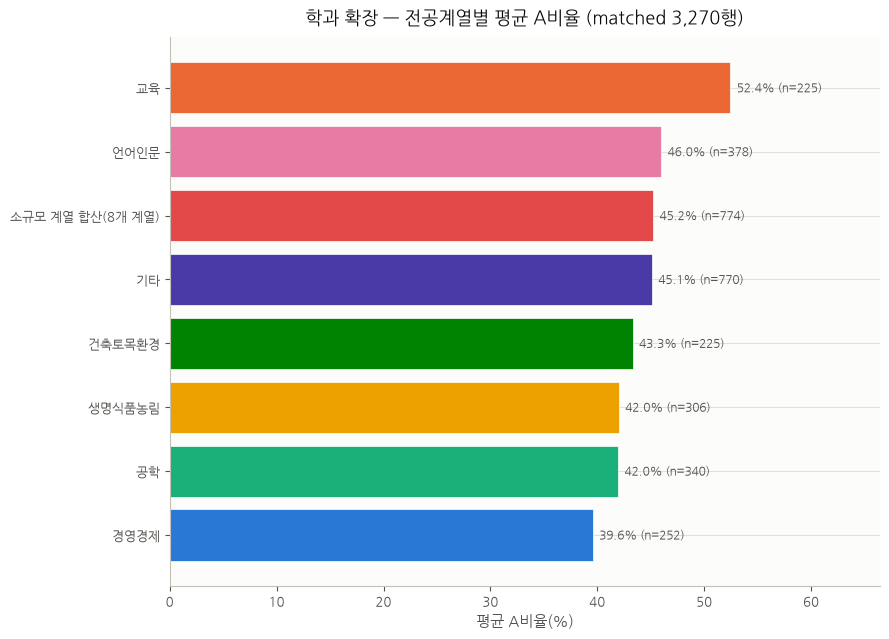


[완료] 차트 저장 위치: /home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2/figures/eda_h1_h2_2024 (총 6개 PNG)

[완료] 산출물 저장 위치: /home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_2/data/eda_h1_h2_2024


In [1]:
# ============================================================================
# H1/H2/H3 기술통계 + 추정통계 + 시각화 EDA (단일 셀)
# 표본: university_analysis_table_2024.csv (대학 단위 47행) +
#      department_analysis_table_2024.csv (대학-학과 확장, matched 행)
# 방법: 기술통계(describe/분위수) + Spearman/Kendall + Bootstrap CI +
#      Welch t-test / Mann-Whitney U / Hedges g + Kruskal-Wallis(epsilon^2) +
#      OLS(HC3 로버스트 SE) + 학과 확장 클러스터-로버스트(대학단위) 회귀
# 산출: data/eda_h1_h2_2024/*.csv (재현 가능한 표) + figures/eda_h1_h2_2024/*.png (차트)
# ============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

RNG_SEED = 42
N_BOOT = 5000

BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR / "data" / "eda_h1_h2_2024"
FIG_DIR = BASE_DIR / "figures" / "eda_h1_h2_2024"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- 한글 폰트 (프로젝트 공통 패턴) ----
KOREAN_FONT_PATHS = [
    Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
]
KOREAN_FONT_FAMILY = None
for _fp in KOREAN_FONT_PATHS:
    if _fp.exists():
        fm.fontManager.addfont(str(_fp))
        KOREAN_FONT_FAMILY = fm.FontProperties(fname=str(_fp)).get_name()
        break
if KOREAN_FONT_FAMILY is None:
    KOREAN_FONT_FAMILY = "DejaVu Sans"
plt.rcParams["font.family"] = KOREAN_FONT_FAMILY
plt.rcParams["font.sans-serif"] = [KOREAN_FONT_FAMILY]
plt.rcParams["axes.unicode_minus"] = False

# ---- 팔레트 (dataviz 스킬 검증 팔레트: CVD-safe 고정 순서) ----
PAL = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT_ORDER = ["blue", "aqua", "yellow", "green", "violet", "red", "magenta", "orange"]
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID_COLOR, BASELINE_COLOR, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GRAY_MID = "#f0efec"


def style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=13, color=INK_PRIMARY, pad=10)
    ax.set_xlabel(xlabel, fontsize=10.5, color=INK_SECONDARY)
    ax.set_ylabel(ylabel, fontsize=10.5, color=INK_SECONDARY)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BASELINE_COLOR)
    ax.spines["bottom"].set_color(BASELINE_COLOR)
    ax.tick_params(colors=INK_SECONDARY, labelsize=9.5)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_facecolor(SURFACE)


def save_fig(fig, filename):
    fig.tight_layout()
    path = FIG_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    return path


uni = pd.read_csv(BASE_DIR / "data" / "analysis_csv" / "university_analysis_table_2024.csv")
dept = pd.read_csv(BASE_DIR / "data" / "analysis_csv" / "department_analysis_table_2024.csv")


# ---------------------------------------------------------------------------
# 공용 함수
# ---------------------------------------------------------------------------
def bootstrap_ci(stat_func, data, n_boot=N_BOOT, seed=RNG_SEED, alpha=0.05):
    """행 단위 리샘플링 부트스트랩. NaN 나오는 반복은 제외."""
    rng = np.random.default_rng(seed)
    n_obs = len(data)
    boots = []
    for _ in range(n_boot):
        samp = data.iloc[rng.integers(0, n_obs, n_obs)]
        v = stat_func(samp)
        if v is not None and np.isfinite(v):
            boots.append(v)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi


def hedges_g(x, y):
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    d = (x.mean() - y.mean()) / pooled_sd
    correction = 1 - 3 / (4 * (nx + ny) - 9)
    return d * correction


def kruskal_epsilon2(groups):
    H, p = stats.kruskal(*groups)
    k = len(groups)
    n_tot = sum(len(g) for g in groups)
    eps2 = (H - k + 1) / (n_tot - k)
    return H, p, eps2


# ===========================================================================
# 1. 대학 단위 기술통계
# ===========================================================================
print("=" * 90)
print("1. 대학 단위 기술통계 (n=%d)" % len(uni))
print("=" * 90)

desc_vars = {
    "rank_2024_raw": "2024년 순위 원점수", "prestige_score": "상위도 점수",
    "a_rate_pct": "A비율", "b_rate_pct": "B비율", "c_rate_pct": "C비율",
    "d_rate_pct": "D비율", "f_rate_pct": "F비율", "df_rate_pct": "D+F비율",
    "credit_forfeit_bin": "학점포기제 O=1",
    "official_employment_rate_pct": "공식취업률", "health_employment_rate_pct": "건보직장가입 취업률",
    "retention_4th_pct": "4차 유지취업률",
    "overall_advancement_rate_pct": "전체 진학률", "graduate_school_rate_pct": "대학원 진학률",
}

rows = []
for col, label in desc_vars.items():
    s = uni[col]
    valid = s.dropna()
    rows.append({
        "variable": col, "label_ko": label, "n": len(valid), "missing": s.isna().sum(),
        "mean": valid.mean(), "std": valid.std(),
        "min": valid.min(), "p10": valid.quantile(.10), "p25": valid.quantile(.25),
        "median": valid.median(), "p75": valid.quantile(.75), "p90": valid.quantile(.90),
        "max": valid.max(), "iqr": valid.quantile(.75) - valid.quantile(.25),
    })
desc_df = pd.DataFrame(rows)
print(desc_df.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

a = uni["a_rate_pct"]
print(f"\n47개교 A비율 평균 {a.mean():.2f}%, 중앙값 {a.median():.2f}%, "
      f"최소 {a.min():.2f}%, 최대 {a.max():.2f}%")
df_ = uni["df_rate_pct"]
emp = uni["official_employment_rate_pct"]
health = uni["health_employment_rate_pct"]
print(f"D+F비율 평균 {df_.mean():.2f}% / 공식취업률 평균 {emp.mean():.2f}% / "
      f"건보직장가입 취업률 평균 {health.mean():.2f}%")

uni["rank_quartile"] = pd.qcut(
    uni["rank_2024_raw"], 4, labels=["상위 25%", "상위 25~50%", "하위 50~75%", "하위 25%"]
)
qbin = uni.groupby("rank_quartile", observed=True)["a_rate_pct"].agg(
    universities="count", a_rate_mean_pct="mean", a_rate_median_pct="median",
    a_rate_min_pct="min", a_rate_max_pct="max",
).reset_index()
print("\n[순위 급간별 A비율]")
print(qbin.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

kw_groups = [g["a_rate_pct"].to_numpy() for _, g in uni.groupby("rank_quartile", observed=True)]
H_kw, p_kw, eps2_kw = kruskal_epsilon2(kw_groups)
top25 = uni.loc[uni["rank_quartile"] == "상위 25%", "a_rate_pct"].mean()
bot25 = uni.loc[uni["rank_quartile"] == "하위 25%", "a_rate_pct"].mean()
print(f"\n상위25% 평균 {top25:.2f}% vs 하위25% 평균 {bot25:.2f}% (차이 {top25-bot25:.2f}%p)")
print(f"Kruskal-Wallis: H={H_kw:.3f}, p={p_kw:.3f}, epsilon^2={eps2_kw:.3f}")

desc_df.to_csv(OUT_DIR / "01_descriptive_statistics_university_2024.csv", index=False, encoding="utf-8-sig")
qbin.to_csv(OUT_DIR / "01b_rank_quartile_a_rate_2024.csv", index=False, encoding="utf-8-sig")


# ===========================================================================
# 2. H1 — 대학 서열 프록시와 A비율
# ===========================================================================
print("\n" + "=" * 90)
print("2. H1 — 대학 서열 프록시(rank/prestige_score)와 A비율")
print("=" * 90)

rho, p_rho = stats.spearmanr(uni["rank_2024_raw"], uni["a_rate_pct"])
tau, p_tau = stats.kendalltau(uni["rank_2024_raw"], uni["a_rate_pct"])
rho_lo, rho_hi = bootstrap_ci(lambda d: stats.spearmanr(d["rank_2024_raw"], d["a_rate_pct"])[0], uni)

m_h1 = smf.ols("a_rate_pct ~ prestige_score", data=uni).fit(cov_type="HC3")
beta_h1 = m_h1.params["prestige_score"]
ci_h1 = m_h1.conf_int().loc["prestige_score"]
p_h1 = m_h1.pvalues["prestige_score"]

h1_summary = pd.DataFrame([
    {"hypothesis": "H1", "metric": "Spearman(rank_2024_raw, a_rate_pct)",
     "estimate": rho, "ci_low": rho_lo, "ci_high": rho_hi, "p_value": p_rho, "n": len(uni),
     "interpretation": "순위 숫자가 커질수록 A비율이 낮아지는 방향이면 음수"},
    {"hypothesis": "H1", "metric": "Kendall tau-b(rank_2024_raw, a_rate_pct)",
     "estimate": tau, "ci_low": np.nan, "ci_high": np.nan, "p_value": p_tau, "n": len(uni),
     "interpretation": "순위 숫자가 커질수록 A비율이 낮아지는 방향이면 음수"},
    {"hypothesis": "H1", "metric": "OLS HC3 beta: prestige_score -> a_rate_pct",
     "estimate": beta_h1, "ci_low": ci_h1[0], "ci_high": ci_h1[1], "p_value": p_h1, "n": len(uni),
     "interpretation": "상위도 점수가 1 증가할 때 A비율 변화(%p). 방향이 맞으면 양수"},
])
print(h1_summary.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\n해석: Spearman rho={rho:.3f}(p={p_rho:.3f}, 95%CI[{rho_lo:.3f},{rho_hi:.3f}]) → "
      f"{'중간 정도' if 0.3<=abs(rho)<0.5 else ('강한' if abs(rho)>=0.5 else '약한')} 음의 순위상관.")
print(f"상위도 점수 0→1 전체 이동 시 A비율 {beta_h1:+.2f}%p 변화(HC3 p={p_h1:.3f}).")
print("주의: 인과관계 아님 — '서열이 높을수록 A비율이 높은 방향의 연관'까지만 서술 가능.")

h1_summary.to_csv(OUT_DIR / "02_h1_result_summary_2024.csv", index=False, encoding="utf-8-sig")


# ===========================================================================
# 3. H2 — 학점포기제 O/X와 A비율
# ===========================================================================
print("\n" + "=" * 90)
print("3. H2 — 학점포기제 O/X와 A비율")
print("=" * 90)

h2 = uni.dropna(subset=["credit_forfeit_bin"]).copy()
missing_univs = uni.loc[uni["credit_forfeit_bin"].isna(), "univ_name_std"].tolist()
o_grp = h2.loc[h2["credit_forfeit_bin"] == 1, "a_rate_pct"]
x_grp = h2.loc[h2["credit_forfeit_bin"] == 0, "a_rate_pct"]

cf_group = h2.groupby(h2["credit_forfeit_bin"].map({1: "O", 0: "X"}))["a_rate_pct"].agg(
    universities="count", a_rate_mean_pct="mean", a_rate_median_pct="median", a_rate_std_pct="std",
).reset_index().rename(columns={"credit_forfeit_bin": "credit_forfeit_raw"})
print(f"학점포기제 유무 결측 {uni['credit_forfeit_bin'].isna().sum()}개교: {missing_univs}")
print(cf_group.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

mean_diff = o_grp.mean() - x_grp.mean()
diff_lo, diff_hi = bootstrap_ci(
    lambda d: d.loc[d["credit_forfeit_bin"] == 1, "a_rate_pct"].mean()
    - d.loc[d["credit_forfeit_bin"] == 0, "a_rate_pct"].mean(), h2)
t_stat, p_t = stats.ttest_ind(o_grp, x_grp, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(o_grp, x_grp)
g_h2 = hedges_g(o_grp, x_grp)

m_h2 = smf.ols("a_rate_pct ~ credit_forfeit_bin + prestige_score", data=h2).fit(cov_type="HC3")
beta_h2 = m_h2.params["credit_forfeit_bin"]
ci_h2 = m_h2.conf_int().loc["credit_forfeit_bin"]
p_h2 = m_h2.pvalues["credit_forfeit_bin"]

h2_summary = pd.DataFrame([
    {"hypothesis": "H2", "metric": "mean(A rate O - X)", "estimate": mean_diff,
     "ci_low": diff_lo, "ci_high": diff_hi, "p_value": np.nan, "effect_size": g_h2, "n": len(h2),
     "interpretation": "양수이면 학점포기제 O 대학의 평균 A비율이 높음"},
    {"hypothesis": "H2", "metric": "Welch t-test two-sided", "estimate": t_stat,
     "ci_low": np.nan, "ci_high": np.nan, "p_value": p_t, "effect_size": g_h2, "n": len(h2),
     "interpretation": "O/X 평균 차이에 대한 이분산 t 검정"},
    {"hypothesis": "H2", "metric": "Mann-Whitney U two-sided", "estimate": u_stat,
     "ci_low": np.nan, "ci_high": np.nan, "p_value": p_u, "effect_size": np.nan, "n": len(h2),
     "interpretation": "O/X 분포 차이에 대한 비모수 검정"},
    {"hypothesis": "H2", "metric": "OLS HC3 beta: credit_forfeit_bin -> a_rate_pct, controlling prestige_score",
     "estimate": beta_h2, "ci_low": ci_h2[0], "ci_high": ci_h2[1], "p_value": p_h2,
     "effect_size": np.nan, "n": len(h2),
     "interpretation": "서열 프록시 통제 후 학점포기제 O의 A비율 차이(%p)"},
])
print("\n" + h2_summary.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\n해석: O-X 평균차 {mean_diff:+.2f}%p (bootstrap 95%CI [{diff_lo:.2f},{diff_hi:.2f}]), "
      f"Welch p={p_t:.3f}, Hedges g={g_h2:.3f} → 효과크기 {'작음' if abs(g_h2)<0.2 else '중간'}.")
print(f"서열 통제 회귀: beta={beta_h2:+.2f}%p, p={p_h2:.3f} → "
      f"{'유의하지 않음' if p_h2>0.05 else '유의함'}. 학점포기제 단독으로 A비율 차이를 설명하기 어려움.")

cf_group.to_csv(OUT_DIR / "03b_h2_credit_forfeit_group_summary_2024.csv", index=False, encoding="utf-8-sig")
h2_summary.to_csv(OUT_DIR / "03_h2_result_summary_2024.csv", index=False, encoding="utf-8-sig")


# ===========================================================================
# 4. H3 — 서열 대비 A잔차와 취업/진학 성과
# ===========================================================================
print("\n" + "=" * 90)
print("4. H3 — 서열 대비 A비율 잔차와 취업/진학 성과")
print("=" * 90)

m_resid = smf.ols("a_rate_pct ~ prestige_score", data=uni).fit()
uni["a_rate_expected_by_rank_pct"] = m_resid.predict(uni)
uni["a_rate_residual_pctp"] = uni["a_rate_pct"] - uni["a_rate_expected_by_rank_pct"]
tertile_labels = ["서열 대비 A 낮음", "중간", "서열 대비 A 높음"]
uni["a_residual_group"] = pd.qcut(uni["a_rate_residual_pctp"], 3, labels=tertile_labels)

outcomes = {
    "공식취업률": "official_employment_rate_pct", "건보직장가입 취업률": "health_employment_rate_pct",
    "4차 유지취업률": "retention_4th_pct", "전체 진학률": "overall_advancement_rate_pct",
    "대학원 진학률": "graduate_school_rate_pct",
}
h3_rows = []
for label, col in outcomes.items():
    rho_o, p_o = stats.spearmanr(uni["a_rate_residual_pctp"], uni[col])

    def diff_stat(d, col=col):
        low = d.loc[d["a_residual_group"] == "서열 대비 A 낮음", col].mean()
        rest = d.loc[d["a_residual_group"] != "서열 대비 A 낮음", col].mean()
        return low - rest

    diff_val = diff_stat(uni)
    diff_lo3, diff_hi3 = bootstrap_ci(diff_stat, uni)

    m3 = smf.ols(f"{col} ~ a_rate_residual_pctp + prestige_score", data=uni).fit(cov_type="HC3")
    beta3 = m3.params["a_rate_residual_pctp"]
    ci3 = m3.conf_int().loc["a_rate_residual_pctp"]
    p3 = m3.pvalues["a_rate_residual_pctp"]

    h3_rows += [
        {"hypothesis": "H3", "outcome": label, "metric": "Spearman(A residual, " + label + ")",
         "estimate": rho_o, "ci_low": np.nan, "ci_high": np.nan, "p_value": p_o, "n": len(uni),
         "interpretation": "양수이면 서열 대비 A비율 잔차가 높은 대학일수록 해당 성과가 높음"},
        {"hypothesis": "H3", "outcome": label, "metric": f"mean({label}: low residual tertile - others)",
         "estimate": diff_val, "ci_low": diff_lo3, "ci_high": diff_hi3, "p_value": np.nan, "n": len(uni),
         "interpretation": "음수이면 서열 대비 A 낮음 그룹의 평균 성과가 나머지보다 낮음"},
        {"hypothesis": "H3", "outcome": label, "metric": f"OLS HC3 beta: A residual -> {label}, controlling prestige_score",
         "estimate": beta3, "ci_low": ci3[0], "ci_high": ci3[1], "p_value": p3, "n": len(uni),
         "interpretation": "A비율 잔차 1%p 증가와 성과 지표 변화의 부분 연관"},
    ]

h3_summary = pd.DataFrame(h3_rows)
print(h3_summary.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

group_summary = uni.groupby("a_residual_group", observed=True).agg(
    universities=("univ_id", "count"), rank_median=("rank_2024_raw", "median"),
    a_rate_mean_pct=("a_rate_pct", "mean"), a_residual_mean_pctp=("a_rate_residual_pctp", "mean"),
    official_employment_rate_mean_pct=("official_employment_rate_pct", "mean"),
    health_employment_rate_mean_pct=("health_employment_rate_pct", "mean"),
    retention_4th_mean_pct=("retention_4th_pct", "mean"),
    overall_advancement_rate_mean_pct=("overall_advancement_rate_pct", "mean"),
    graduate_school_rate_mean_pct=("graduate_school_rate_pct", "mean"),
).reset_index()
print("\n[A잔차 3분위 그룹 요약]")
print(group_summary.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

sig_outcomes = h3_summary[(h3_summary["metric"].str.startswith("OLS")) & (h3_summary["p_value"] < 0.05)]
print(f"\n해석: 취업 지표(공식취업률/건보/4차유지)는 A잔차와 유의한 연관 없음. "
      f"진학률 계열에서만 유의 신호: {sig_outcomes[['outcome','estimate','p_value']].to_string(index=False) if len(sig_outcomes) else '없음'}")

low_examples = uni.sort_values("a_rate_residual_pctp").head(5)[["univ_name_std", "a_rate_residual_pctp"]]
print(f"\n잔차가 가장 낮은 대학 5개: {low_examples['univ_name_std'].tolist()}")

h3_summary.to_csv(OUT_DIR / "04_h3_residual_employment_result_summary_2024.csv", index=False, encoding="utf-8-sig")
group_summary.to_csv(OUT_DIR / "05_h3_residual_group_summary_2024.csv", index=False, encoding="utf-8-sig")
low_examples.to_csv(OUT_DIR / "05b_h3_low_a_residual_university_examples_2024.csv", index=False, encoding="utf-8-sig")


# ===========================================================================
# 5. 학과 확장 분석 (대학 단위 클러스터-로버스트 SE)
# ===========================================================================
print("\n" + "=" * 90)
print("5. 학과 확장 분석 — 전공계열 통제 + 대학 단위 클러스터 로버스트 SE")
print("=" * 90)

dept_m = dept[dept["match_status"] == "matched"].dropna(
    subset=["a_rate_pct", "prestige_score", "credit_forfeit_bin", "major_group", "univ_id"]
).copy()
print(f"학과 확장표 전체 {len(dept)}행 중 매칭 {len(dept_m)}행 "
      f"(독립 대학 수={dept_m['univ_id'].nunique()}개 — 표본 크기 아님에 주의)")

m_ext = smf.ols("a_rate_pct ~ prestige_score + credit_forfeit_bin + C(major_group)", data=dept_m).fit(
    cov_type="cluster", cov_kwds={"groups": dept_m["univ_id"]}
)
ext_summary = pd.DataFrame([
    {"metric": "prestige_score -> a_rate_pct (major_group 통제, 대학단위 cluster-robust)",
     "estimate": m_ext.params["prestige_score"],
     "ci_low": m_ext.conf_int().loc["prestige_score", 0], "ci_high": m_ext.conf_int().loc["prestige_score", 1],
     "p_value": m_ext.pvalues["prestige_score"], "n_rows": len(dept_m), "n_universities": dept_m["univ_id"].nunique()},
    {"metric": "credit_forfeit_bin -> a_rate_pct (major_group 통제, 대학단위 cluster-robust)",
     "estimate": m_ext.params["credit_forfeit_bin"],
     "ci_low": m_ext.conf_int().loc["credit_forfeit_bin", 0], "ci_high": m_ext.conf_int().loc["credit_forfeit_bin", 1],
     "p_value": m_ext.pvalues["credit_forfeit_bin"], "n_rows": len(dept_m), "n_universities": dept_m["univ_id"].nunique()},
])
print(ext_summary.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print("\n해석: 학과 행 수가 많아도 독립 대학 표본이 늘어난 게 아니므로, 이 결과는 대학 단위 H1/H2의 "
      "방향이 전공계열을 통제해도 유지되는지 보는 보조 증거로만 사용.")

ext_summary.to_csv(OUT_DIR / "06_department_extension_result_summary_2024.csv", index=False, encoding="utf-8-sig")


# ===========================================================================
# 6. 시각화
# ===========================================================================
print("\n" + "=" * 90)
print("6. 시각화")
print("=" * 90)

# --- Fig 1. 순위 4분위별 A비율 (막대 + 개별 대학 점) -------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
order = ["상위 25%", "상위 25~50%", "하위 50~75%", "하위 25%"]
means = qbin.set_index("rank_quartile").loc[order, "a_rate_mean_pct"]
x_pos = np.arange(len(order))
ax.bar(x_pos, means.values, width=0.55, color=PAL["blue"], zorder=2, edgecolor="white", linewidth=0.5)
for xi, q in zip(x_pos, order):
    pts = uni.loc[uni["rank_quartile"] == q, "a_rate_pct"]
    jitter = (np.random.default_rng(0).random(len(pts)) - 0.5) * 0.18
    ax.scatter(xi + jitter, pts, color=INK_PRIMARY, alpha=0.45, s=22, zorder=3)
    label_y = max(means[q], pts.max()) + 2.2
    ax.text(xi, label_y, f"{means[q]:.1f}%", ha="center", fontsize=9.5, color=INK_PRIMARY, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(order)
style_ax(ax, f"순위 4분위별 A비율 (Kruskal-Wallis H={H_kw:.2f}, p={p_kw:.3f})",
         "2024년 순위 4분위 (상위→하위)", "A비율(%)")
ax.set_ylim(0, max(uni["a_rate_pct"]) + 8)
save_fig(fig, "01_rank_quartile_a_rate_bar.png")

# --- Fig 2. H1 — 상위도 점수 vs A비율 산점도 + 회귀선 ------------------------
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(uni["prestige_score"], uni["a_rate_pct"], color=PAL["blue"], alpha=0.75, s=45,
           edgecolor="white", linewidth=0.4, zorder=3)
xs = np.linspace(0, 1, 100)
ys = m_h1.params["Intercept"] + m_h1.params["prestige_score"] * xs
ax.plot(xs, ys, color=INK_PRIMARY, linewidth=1.8, zorder=2)
top5 = uni.nlargest(5, "a_rate_pct")
bot5 = uni.nsmallest(5, "a_rate_pct")

# top5는 prestige_score가 서로 가까워 라벨이 겹치기 쉬움 -> 우측 고정폭에 세로로 펼치고 리더선 연결
top5_sorted = top5.sort_values("a_rate_pct", ascending=False)
for i, (_, row) in enumerate(top5_sorted.iterrows()):
    label_y = row["a_rate_pct"] + 1.0 - i * 1.4
    ax.annotate(row["univ_name_std"], xy=(row["prestige_score"], row["a_rate_pct"]),
                xytext=(0.995, label_y), textcoords=("axes fraction", "data"),
                ha="right", fontsize=8, color=INK_SECONDARY,
                arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=0.6, shrinkA=0, shrinkB=3))

for _, row in bot5.iterrows():
    ax.annotate(row["univ_name_std"], (row["prestige_score"], row["a_rate_pct"]),
                fontsize=8, color=INK_SECONDARY, xytext=(5, -9), textcoords="offset points")
style_ax(ax, f"H1: 상위도 점수 vs A비율 (Spearman ρ={rho:.2f}, p={p_rho:.3f})",
         "상위도 점수 (0=최하위, 1=최상위)", "A비율(%)")
save_fig(fig, "02_h1_prestige_vs_a_rate_scatter.png")

# --- Fig 3. H2 — 학점포기제 O/X 박스플롯 -------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6))
box_colors = {"X": PAL["orange"], "O": PAL["blue"]}
for i, grp in enumerate(["X", "O"]):
    vals = h2.loc[h2["credit_forfeit_bin"] == (1 if grp == "O" else 0), "a_rate_pct"]
    bp = ax.boxplot(vals, positions=[i], widths=0.45, patch_artist=True, showfliers=False,
                     medianprops={"color": INK_PRIMARY, "linewidth": 1.6},
                     whiskerprops={"color": BASELINE_COLOR}, capprops={"color": BASELINE_COLOR})
    bp["boxes"][0].set_facecolor(box_colors[grp])
    bp["boxes"][0].set_alpha(0.55)
    bp["boxes"][0].set_edgecolor(box_colors[grp])
    jitter = (np.random.default_rng(1).random(len(vals)) - 0.5) * 0.18
    ax.scatter(i + jitter, vals, color=INK_PRIMARY, alpha=0.55, s=28, zorder=3)
    ax.text(i, vals.max() + 2.0, f"n={len(vals)}, mean={vals.mean():.1f}%", ha="center", fontsize=8.5, color=INK_SECONDARY)
ax.set_xticks([0, 1])
ax.set_xticklabels(["X (미시행)", "O (시행)"])
ax.set_ylim(top=uni["a_rate_pct"].max() + 6)
style_ax(ax, f"H2: 학점포기제 O/X와 A비율 (Welch p={p_t:.3f}, Hedges g={g_h2:.2f})",
         "학점포기제 유무", "A비율(%)")
save_fig(fig, "03_h2_credit_forfeit_box.png")

# --- Fig 4. H3 — A잔차 3분위 그룹별 성과지표 (다이버징 색) --------------------
fig, ax = plt.subplots(figsize=(10, 6))
outcome_cols = list(outcomes.items())
group_colors = {"서열 대비 A 낮음": PAL["blue"], "중간": INK_MUTED, "서열 대비 A 높음": PAL["red"]}
n_out = len(outcome_cols)
bar_w = 0.25
x_base = np.arange(n_out)
colmap = {
    "official_employment_rate_pct": "official_employment_rate_mean_pct",
    "health_employment_rate_pct": "health_employment_rate_mean_pct",
    "retention_4th_pct": "retention_4th_mean_pct",
    "overall_advancement_rate_pct": "overall_advancement_rate_mean_pct",
    "graduate_school_rate_pct": "graduate_school_rate_mean_pct",
}
for gi, grp in enumerate(tertile_labels):
    vals = [group_summary.set_index("a_residual_group").loc[grp, colmap[col]] for _, col in outcome_cols]
    ax.bar(x_base + (gi - 1) * bar_w, vals, width=bar_w, color=group_colors[grp], label=grp,
           edgecolor="white", linewidth=0.5, zorder=2)
ax.set_xticks(x_base)
ax.set_xticklabels([label for label, _ in outcome_cols], fontsize=9.5)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
style_ax(ax, "H3: 서열 대비 A잔차 3분위 그룹별 성과지표 평균", "성과지표", "평균(%)")
save_fig(fig, "04_h3_residual_group_outcomes_bar.png")

# --- Fig 5. H3 — A잔차 vs 전체 진학률 (유의한 관계) --------------------------
fig, ax = plt.subplots(figsize=(8.5, 6))
sig_col = "overall_advancement_rate_pct"
sig_model = smf.ols(f"{sig_col} ~ a_rate_residual_pctp + prestige_score", data=uni).fit()
ax.scatter(uni["a_rate_residual_pctp"], uni[sig_col], color=PAL["violet"], alpha=0.75, s=45,
           edgecolor="white", linewidth=0.4, zorder=3)
xs2 = np.linspace(uni["a_rate_residual_pctp"].min(), uni["a_rate_residual_pctp"].max(), 100)
mean_prestige = uni["prestige_score"].mean()
ys2 = (sig_model.params["Intercept"] + sig_model.params["a_rate_residual_pctp"] * xs2
       + sig_model.params["prestige_score"] * mean_prestige)
ax.plot(xs2, ys2, color=INK_PRIMARY, linewidth=1.8, zorder=2)
ax.axvline(0, color=BASELINE_COLOR, linewidth=1, linestyle="--", zorder=1)
h3_beta_row = h3_summary[(h3_summary["outcome"] == "전체 진학률") & (h3_summary["metric"].str.startswith("OLS"))].iloc[0]
style_ax(ax, f"H3: A비율 잔차 vs 전체 진학률 (HC3 β={h3_beta_row['estimate']:.2f}, p={h3_beta_row['p_value']:.3f})",
         "A비율 잔차(%p, 서열 기대치 대비)", "전체 진학률(%)")
save_fig(fig, "05_h3_residual_vs_advancement_scatter.png")

# --- Fig 6. 학과 확장 — 전공계열별 평균 A비율 --------------------------------
# 팔레트가 8색이므로 상위 7개 계열 + '소규모 계열 합산' 1개로 맞춰 색상 중복을 피함
major_stats = dept_m.groupby("major_group")["a_rate_pct"].agg(n="count", mean="mean").reset_index()
major_stats = major_stats.sort_values("n", ascending=False)
top7 = major_stats.head(7).copy()
rest = major_stats.iloc[7:]
if len(rest):
    rest_mean = (dept_m[dept_m["major_group"].isin(rest["major_group"])]["a_rate_pct"]).mean()
    top7 = pd.concat([top7, pd.DataFrame([{"major_group": f"소규모 계열 합산({len(rest)}개 계열)", "n": rest["n"].sum(), "mean": rest_mean}])],
                      ignore_index=True)
    print(f"[표시 제한] 표본이 작은 {len(rest)}개 전공계열({', '.join(rest['major_group'])}, 합계 n={rest['n'].sum()})은 "
          f"'소규모 계열 합산'로 묶어 표시. 세부 수치는 06 CSV에서 major_group별로 확인 가능.")
top7 = top7.sort_values("mean", ascending=True)
fig, ax = plt.subplots(figsize=(9, 6.5))
colors = [PAL[CAT_ORDER[i % len(CAT_ORDER)]] for i in range(len(top7))]
bars = ax.barh(top7["major_group"], top7["mean"], color=colors, edgecolor="white", linewidth=0.5, zorder=2)
for bar, n_val in zip(bars, top7["n"]):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.1f}% (n={n_val:,})",
            va="center", fontsize=8.5, color=INK_SECONDARY)
style_ax(ax, f"학과 확장 — 전공계열별 평균 A비율 (matched {len(dept_m):,}행)", "평균 A비율(%)", "")
ax.set_xlim(0, top7["mean"].max() + 14)
save_fig(fig, "06_department_major_group_a_rate_bar.png")

print(f"\n[완료] 차트 저장 위치: {FIG_DIR} (총 6개 PNG)")

print("\n" + "=" * 90)
print(f"[완료] 산출물 저장 위치: {OUT_DIR}")
print("=" * 90)
